# BT02 - Phân tích khám phá và tiền xử lý dữ liệu
## Code Python chạy trên Anaconda / Jupyter Notebook
Đánh số và tổ chức phần thực hành bám đúng file BT02.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

## Câu 1 - Tạo dataset

In [9]:
df = pd.DataFrame({
    'ID': [1,2,3,4,5,6,7,8,9,10],
    'Tuổi': [25,30,22,40,35,np.nan,29,50,27,31],
    'Lương': [8000,np.nan,5000,15000,-2000,7000,8500,30000,8200,7800],
    'Điểm': [7.5,8.0,6.5,9.0,7.0,6.0,8.5,9.5,np.nan,7.8],
    'Giới tính': ['Nam','Nữ','Nam','Nữ','Nam','Nữ','Nam','Nữ','Nam','Nữ'],
    'Mua hàng': ['Yes','No','Yes','Yes','No','Yes','Yes','Yes','No','Yes']
})

display(df)

,ID,Tuổi,Lương,Điểm,Giới tính,Mua hàng
0,1,25.0000,8000.0000,7.5000,Nam,Yes
1,2,30.0000,NaN,8.0000,Nữ,No
2,3,22.0000,5000.0000,6.5000,Nam,Yes
3,4,40.0000,15000.0000,9.0000,Nữ,Yes
4,5,35.0000,-2000.0000,7.0000,Nam,No
5,6,NaN,7000.0000,6.0000,Nữ,Yes
6,7,29.0000,8500.0000,8.5000,Nam,Yes
7,8,50.0000,30000.0000,9.5000,Nữ,Yes
8,9,27.0000,8200.0000,NaN,Nam,No
9,10,31.0000,7800.0000,7.8000,Nữ,Yes


## Câu 1.1 - Data Overview


In [10]:
print('Số lượng mẫu:', len(df))
print('Số thuộc tính:', len(df.columns))

overview = pd.DataFrame({
    'Thuộc tính': df.columns,
    'Kiểu dữ liệu': [
        'Categorical (ID)', 'Numerical', 'Numerical', 'Numerical',
        'Categorical', 'Categorical'
    ]
})
display(overview)

Số lượng mẫu: 10
Số thuộc tính: 6


,Thuộc tính,Kiểu dữ liệu
0,ID,Categorical (ID)
1,Tuổi,Numerical
2,Lương,Numerical
3,Điểm,Numerical
4,Giới tính,Categorical
5,Mua hàng,Categorical


## Câu 1.2 - Descriptive Statistics


In [11]:
numeric_cols = ['Tuổi', 'Lương', 'Điểm']

stats_table = pd.DataFrame({
    'Mean': df[numeric_cols].mean(),
    'Median': df[numeric_cols].median(),
    'Mode': [df[c].mode().tolist() for c in numeric_cols]
})
display(stats_table)

,Mean,Median,Mode
Tuổi,32.1111,30.0000,"[22.0, 25.0, 27.0, 29.0, 30.0, 31.0, 35.0, 40...."
Lương,9722.2222,8000.0000,"[-2000.0, 5000.0, 7000.0, 7800.0, 8000.0, 8200..."
Điểm,7.7556,7.8000,"[6.0, 6.5, 7.0, 7.5, 7.8, 8.0, 8.5, 9.0, 9.5]"


## Câu 1.3 - Distribution Analysis

Histogram Tuổi và Boxplot Lương. Tính skewness để hỗ trợ nhận xét phân phối.

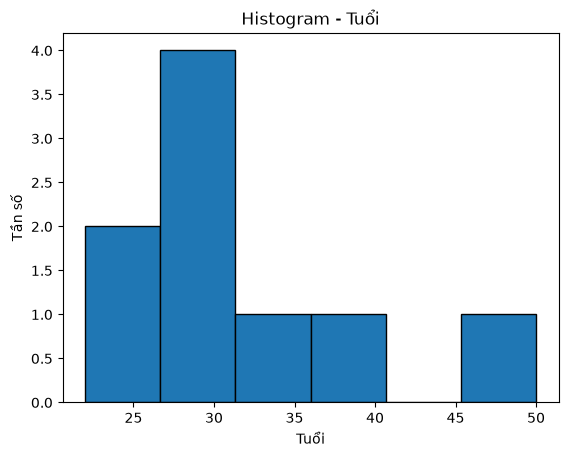

C:\Users\Khoa\AppData\Local\Temp\ipykernel_13872\2656607572.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df['Lương'].dropna(), vert=True)


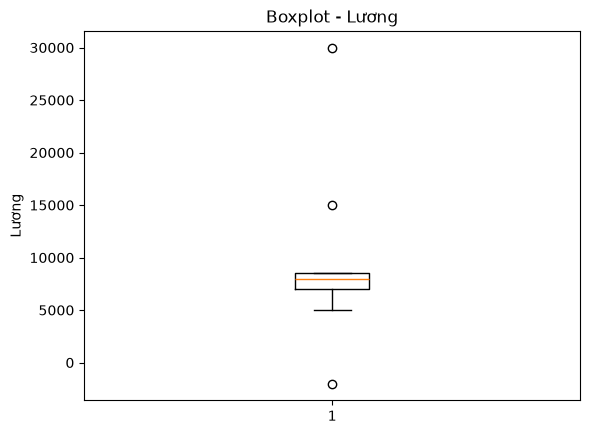

In [12]:
fig, ax = plt.subplots()
ax.hist(df['Tuổi'].dropna(), bins=6, edgecolor='black')
ax.set_title('Histogram - Tuổi')
ax.set_xlabel('Tuổi')
ax.set_ylabel('Tần số')
plt.show()

fig, ax = plt.subplots()
ax.boxplot(df['Lương'].dropna(), vert=True)
ax.set_title('Boxplot - Lương')
ax.set_ylabel('Lương')
plt.show()

### Câu 1.3 - Skewness và kiểm tra ảnh hưởng của outlier

Phần này vẫn thuộc Câu 1.3, không phải Câu 1.4.

In [13]:
salary = df['Lương'].dropna()
print('Skewness Lương:', salary.skew())

Q1 = salary.quantile(0.25)
Q3 = salary.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_salary = df[(df['Lương'] < lower) | (df['Lương'] > upper)]
print('Q1 =', Q1, '| Q3 =', Q3, '| IQR =', IQR)
print('Ngưỡng dưới =', lower, '| Ngưỡng trên =', upper)
print('Outlier theo IQR:')
display(outliers_salary[['ID','Lương']])

Skewness Lương: 1.5985976462429485
Q1 = 7000.0 | Q3 = 8500.0 | IQR = 1500.0
Ngưỡng dưới = 4750.0 | Ngưỡng trên = 10750.0
Outlier theo IQR:


,ID,Lương
3,4,15000.0000
4,5,-2000.0000
7,8,30000.0000


## Câu 1.4 - Relationship Analysis

Vẽ Scatter plot giữa Tuổi và Lương và tính hệ số tương quan Pearson.

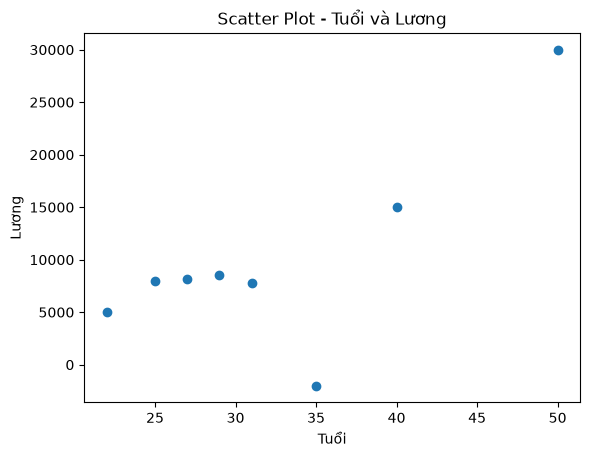

Hệ số tương quan Pearson: 0.7467585603330041


In [14]:
plot_df = df[['Tuổi','Lương']].dropna()

fig, ax = plt.subplots()
ax.scatter(plot_df['Tuổi'], plot_df['Lương'])
ax.set_title('Scatter Plot - Tuổi và Lương')
ax.set_xlabel('Tuổi')
ax.set_ylabel('Lương')
plt.show()

print('Hệ số tương quan Pearson:', plot_df['Tuổi'].corr(plot_df['Lương']))

## Câu 1.5 - EDA: Missing Data


In [15]:
missing_count = df.isna().sum()
missing_percent = df.isna().mean() * 100

missing_table = pd.DataFrame({
    'Số lượng missing': missing_count,
    'Tỷ lệ missing (%)': missing_percent
})
display(missing_table)

print('Các dòng có missing:')
display(df[df.isna().any(axis=1)])

,Số lượng missing,Tỷ lệ missing (%)
ID,0,0.0000
Tuổi,1,10.0000
Lương,1,10.0000
Điểm,1,10.0000
Giới tính,0,0.0000
Mua hàng,0,0.0000


Các dòng có missing:


,ID,Tuổi,Lương,Điểm,Giới tính,Mua hàng
1,2,30.0000,NaN,8.0000,Nữ,No
5,6,NaN,7000.0000,6.0000,Nữ,Yes
8,9,27.0000,8200.0000,NaN,Nam,No


## Câu 1.6 - Missing Data Processing


In [16]:
df_mean = df.copy()
df_median = df.copy()

for col in ['Tuổi', 'Lương', 'Điểm']:
    df_mean[col] = df_mean[col].fillna(df_mean[col].mean())
    df_median[col] = df_median[col].fillna(df_median[col].median())

print('Điền bằng Mean:')
display(df_mean)

print('Điền bằng Median:')
display(df_median)

Điền bằng Mean:


,ID,Tuổi,Lương,Điểm,Giới tính,Mua hàng
0,1,25.0000,8000.0000,7.5000,Nam,Yes
1,2,30.0000,9722.2222,8.0000,Nữ,No
2,3,22.0000,5000.0000,6.5000,Nam,Yes
3,4,40.0000,15000.0000,9.0000,Nữ,Yes
4,5,35.0000,-2000.0000,7.0000,Nam,No
5,6,32.1111,7000.0000,6.0000,Nữ,Yes
6,7,29.0000,8500.0000,8.5000,Nam,Yes
7,8,50.0000,30000.0000,9.5000,Nữ,Yes
8,9,27.0000,8200.0000,7.7556,Nam,No
9,10,31.0000,7800.0000,7.8000,Nữ,Yes


Điền bằng Median:


,ID,Tuổi,Lương,Điểm,Giới tính,Mua hàng
0,1,25.0000,8000.0000,7.5000,Nam,Yes
1,2,30.0000,8000.0000,8.0000,Nữ,No
2,3,22.0000,5000.0000,6.5000,Nam,Yes
3,4,40.0000,15000.0000,9.0000,Nữ,Yes
4,5,35.0000,-2000.0000,7.0000,Nam,No
5,6,30.0000,7000.0000,6.0000,Nữ,Yes
6,7,29.0000,8500.0000,8.5000,Nam,Yes
7,8,50.0000,30000.0000,9.5000,Nữ,Yes
8,9,27.0000,8200.0000,7.8000,Nam,No
9,10,31.0000,7800.0000,7.8000,Nữ,Yes


## Câu 1.7 - Data Quality


In [17]:
print('Giá trị Lương âm:')
display(df[df['Lương'] < 0])

print('Điểm ngoài miền 0-10:')
display(df[(df['Điểm'] < 0) | (df['Điểm'] > 10)])

print('Tuổi ngoài miền hợp lý đã xét:')
display(df[(df['Tuổi'] < 0) | (df['Tuổi'] > 100)])

Giá trị Lương âm:


,ID,Tuổi,Lương,Điểm,Giới tính,Mua hàng
4,5,35.0000,-2000.0000,7.0000,Nam,No


Điểm ngoài miền 0-10:


,ID,Tuổi,Lương,Điểm,Giới tính,Mua hàng


Tuổi ngoài miền hợp lý đã xét:


,ID,Tuổi,Lương,Điểm,Giới tính,Mua hàng


## Câu 1.8 - Outlier Detection bằng IQR


In [18]:
salary_valid = df['Lương'].dropna()

# IQR
q1 = salary_valid.quantile(0.25)
q3 = salary_valid.quantile(0.75)
iqr = q3 - q1
iqr_outliers = salary_valid[(salary_valid < q1 - 1.5*iqr) | (salary_valid > q3 + 1.5*iqr)]

print('Outlier theo IQR:')
display(iqr_outliers)


Outlier theo IQR:


3   15000.0000
4   -2000.0000
7   30000.0000
Name: Lương, dtype: float64

## Câu 1.9 - Z-score Normalization


In [19]:
salary_valid = df['Lương'].dropna()
z_scores = pd.Series(stats.zscore(salary_valid), index=salary_valid.index)

z_table = pd.DataFrame({'Lương': salary_valid, 'Z-score': z_scores})
display(z_table)

print('Outlier theo Z-score |z| > 3:')
display(z_table[z_table['Z-score'].abs() > 3])

,Lương,Z-score
0,8000.0000,-0.2081
2,5000.0000,-0.5705
3,15000.0000,0.6376
4,-2000.0000,-1.4162
5,7000.0000,-0.3289
6,8500.0000,-0.1477
7,30000.0000,2.4498
8,8200.0000,-0.1839
9,7800.0000,-0.2322


Outlier theo Z-score |z| > 3:


,Lương,Z-score


In [20]:
df_z = df.copy()
mean_salary = df_z['Lương'].mean()
std_salary = df_z['Lương'].std()
df_z['Lương_Zscore'] = (df_z['Lương'] - mean_salary) / std_salary

display(df_z[['ID','Lương','Lương_Zscore']])
print('Mean sau chuẩn hóa:', df_z['Lương_Zscore'].mean())
print('Std sau chuẩn hóa:', df_z['Lương_Zscore'].std())

,ID,Lương,Lương_Zscore
0,1,8000.0000,-0.1962
1,2,NaN,NaN
2,3,5000.0000,-0.5379
3,4,15000.0000,0.6011
4,5,-2000.0000,-1.3352
5,6,7000.0000,-0.3101
6,7,8500.0000,-0.1392
7,8,30000.0000,2.3097
8,9,8200.0000,-0.1734
9,10,7800.0000,-0.2189


Mean sau chuẩn hóa: -5.2427198385076835e-17
Std sau chuẩn hóa: 1.0


## Câu 1.10 - Encoding


In [21]:
encoded = pd.get_dummies(df, columns=['Giới tính'], dtype=int)
encoded['Mua hàng'] = encoded['Mua hàng'].map({'No': 0, 'Yes': 1})
display(encoded)

,ID,Tuổi,Lương,Điểm,Mua hàng,Giới tính_Nam,Giới tính_Nữ
0,1,25.0000,8000.0000,7.5000,1,1,0
1,2,30.0000,NaN,8.0000,0,0,1
2,3,22.0000,5000.0000,6.5000,1,1,0
3,4,40.0000,15000.0000,9.0000,1,0,1
4,5,35.0000,-2000.0000,7.0000,0,1,0
5,6,NaN,7000.0000,6.0000,1,0,1
6,7,29.0000,8500.0000,8.5000,1,1,0
7,8,50.0000,30000.0000,9.5000,1,0,1
8,9,27.0000,8200.0000,NaN,0,1,0
9,10,31.0000,7800.0000,7.8000,1,0,1


## Câu 1.11 - Feature Selection


In [22]:
feature_check = pd.DataFrame({
    'Thuộc tính': ['ID','Tuổi','Lương','Điểm','Giới tính','Mua hàng'],
    'Giữ/Loại': ['Loại','Giữ','Giữ','Giữ','Giữ','Target/giữ tùy bài toán'],
    'Lý do': [
        'ID chỉ định danh, không mang ý nghĩa dự đoán',
        'Có thể liên quan đến hành vi/thu nhập',
        'Có giá trị bất thường -2000 và missing, cần xử lý',
        'Có missing, cần xử lý',
        'Có thể dùng sau encoding',
        'Có thể là biến mục tiêu nếu dự đoán mua hàng'
    ]
})
display(feature_check)

,Thuộc tính,Giữ/Loại,Lý do
0,ID,Loại,"ID chỉ định danh, không mang ý nghĩa dự đoán"
1,Tuổi,Giữ,Có thể liên quan đến hành vi/thu nhập
2,Lương,Giữ,"Có giá trị bất thường -2000 và missing, cần xử lý"
3,Điểm,Giữ,"Có missing, cần xử lý"
4,Giới tính,Giữ,Có thể dùng sau encoding
5,Mua hàng,Target/giữ tùy bài toán,Có thể là biến mục tiêu nếu dự đoán mua hàng


## Câu 1.12 - Data Reduction


In [23]:
from sklearn.decomposition import PCA

# Dùng các biến số sau khi xử lý missing và loại giá trị lương âm
pca_df = df[['Tuổi','Lương','Điểm']].copy()
pca_df['Lương'] = pca_df['Lương'].replace(-2000, np.nan)
pca_df = pca_df.fillna(pca_df.median())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(pca_df)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_result = pd.DataFrame(X_pca, columns=['PC1','PC2'])
display(pca_result)
print('Explained variance ratio:', pca.explained_variance_ratio_)
print('Tổng phương sai giữ lại:', pca.explained_variance_ratio_.sum())

,PC1,PC2
0,-0.8891,0.3230
1,-0.2330,0.4150
2,-1.9090,-0.1782
3,1.6615,0.3208
4,-0.3798,-0.7062
5,-1.3876,-1.1625
6,-0.0100,0.8661
7,3.9953,-0.5156
8,-0.5598,0.4343
9,-0.2884,0.2032


Explained variance ratio: [0.85596052 0.11690657]
Tổng phương sai giữ lại: 0.9728670850832725


## Câu 2.1 - Phân tích tập tuổi


In [24]:
ages = np.array([13,15,16,16,19,20,20,21,22,22,25,25,25,25,30,33,33,35,35,35,35,36,40,45,46,52,70])
age_series = pd.Series(ages)

print('Số phần tử:', len(ages))
print('Mean:', age_series.mean())
print('Median:', age_series.median())
print('Mode:', age_series.mode().tolist())
print('Q1:', age_series.quantile(0.25))
print('Q3:', age_series.quantile(0.75))

Số phần tử: 27
Mean: 29.962962962962962
Median: 25.0
Mode: [25, 35]
Q1: 20.5
Q3: 35.0


## Câu 2.1 - Boxplot và Outlier


C:\Users\Khoa\AppData\Local\Temp\ipykernel_13872\3812372383.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(ages, vert=True)


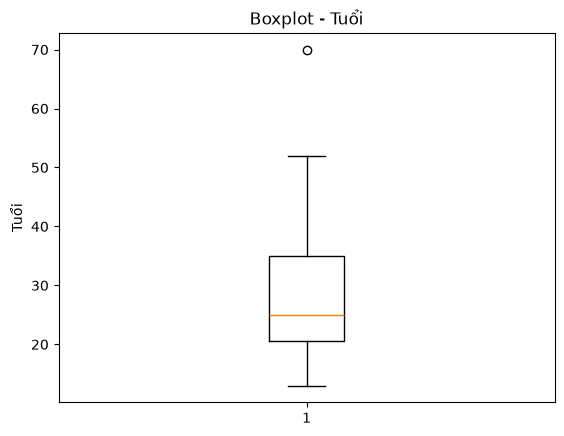

Q1 = 20.5 | Q3 = 35.0 | IQR = 14.5
Outlier: [70]


In [25]:
fig, ax = plt.subplots()
ax.boxplot(ages, vert=True)
ax.set_title('Boxplot - Tuổi')
ax.set_ylabel('Tuổi')
plt.show()

q1 = np.quantile(ages, 0.25)
q3 = np.quantile(ages, 0.75)
iqr = q3 - q1
lower = q1 - 1.5*iqr
upper = q3 + 1.5*iqr
age_outliers = ages[(ages < lower) | (ages > upper)]
print('Q1 =', q1, '| Q3 =', q3, '| IQR =', iqr)
print('Outlier:', age_outliers)

### Câu 2d - Rời rạc hóa với k = 4
Có cả hai cách thường dùng: chia đều khoảng (equal-width) và chia theo tần số (equal-frequency).

In [26]:
k = 4

# Equal-width
equal_width = pd.cut(age_series, bins=k, include_lowest=True)
print('Equal-width:')
display(pd.DataFrame({'Tuổi': ages, 'Bin': equal_width}))

# Equal-frequency
equal_frequency = pd.qcut(age_series, q=k, duplicates='drop')
print('Equal-frequency:')
display(pd.DataFrame({'Tuổi': ages, 'Bin': equal_frequency}))

Equal-width:


,Tuổi,Bin
0,13,"(12.942, 27.25]"
1,15,"(12.942, 27.25]"
2,16,"(12.942, 27.25]"
3,16,"(12.942, 27.25]"
4,19,"(12.942, 27.25]"
5,20,"(12.942, 27.25]"
6,20,"(12.942, 27.25]"
7,21,"(12.942, 27.25]"
8,22,"(12.942, 27.25]"
9,22,"(12.942, 27.25]"


Equal-frequency:


,Tuổi,Bin
0,13,"(12.999, 20.5]"
1,15,"(12.999, 20.5]"
2,16,"(12.999, 20.5]"
3,16,"(12.999, 20.5]"
4,19,"(12.999, 20.5]"
5,20,"(12.999, 20.5]"
6,20,"(12.999, 20.5]"
7,21,"(20.5, 25.0]"
8,22,"(20.5, 25.0]"
9,22,"(20.5, 25.0]"


## Câu 3 - Thang đo
Phần bảng trong file DL01 hiện chỉ hiển thị các cột A-E và các dãy số; đề không cung cấp rõ biểu thức/định nghĩa V(.) và W1-W6 trong phần văn bản trích xuất. Vì vậy không tự đoán đáp án phần này.

In [ ]:
# Nếu giảng viên cung cấp đầy đủ bảng V(.) và W1-W6, có thể bổ sung phần này tại đây.
print('Câu 3 cần bảng/ảnh đầy đủ của V(.) và W1-W6 để xác định chính xác.')

## Ghi chú chạy trên Anaconda
Nếu máy chưa có thư viện, chạy trong Anaconda Prompt/Jupyter:
```bash
conda install pandas numpy matplotlib scipy scikit-learn
```
Sau đó mở file này bằng Jupyter Notebook hoặc JupyterLab.